<a href="https://colab.research.google.com/github/hubert-marek/cs-166/blob/main/airport_security_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS166 First Project: Airport Security Queues

We simulate airport security as an M/G/k queueing system. Travelers arrive at random (a Poisson
process), join the shortest line, and each line has one screening station with a random,
truncated-normal service time. In the extended model, a few travelers also need extra screening
from a single senior officer.

**Code map**

```
Simulation (Sections 1-3)
run_simulation(scenario, num_queues, run_until)
 ├── Schedule ........... heap of Events; run_until() always runs the earliest one next
 └── Airport(scenario) .. BASIC_MODEL or EXTENDED_MODEL (a Scenario)
       ├── Sampler x 3 ..... arrival gaps, service times, screening times (drawn in batches)
       ├── choose_queue() .. shortest queue (Queue.__lt__)
       ├── Queue x k ....... one line + one service station
       └── SeniorOfficer ... extra screening, one traveler at a time

Event flow (one traveler)
  Airport.add_traveler    joins the shortest queue and schedules the next arrival
  Queue.add_traveler      waits in line (starts service right away if the station is free)
  Queue.start_service     reaches the station and draws a service time
  Queue.finish_service    97%: Queue.release_station
                          3%:  SeniorOfficer.request -> start_screening -> finish_screening
                               -> Queue.release_station (the station stays blocked until then)
  Queue.release_station   frees the station and starts the next traveler in line

Measuring and analysis (Section 4)
  run_simulation -> collect_metrics ....... six metrics of one run, after the warm-up
  repeat_runs ----> mean_and_ci ........... mean ± 95% CI over independent runs
  study ----------> repeat_runs for each k  staffing tables (Section 6); meets_targets checks targets
  test_case, warmup_check ................. test cases and warm-up checks (Sections 5 and 6)
  mg1_wait_time, mgk_wait_time ............ queueing theory (Section 6.1)
  waiting_over_time, plot_metric, measurable  data and helpers for the plots
```

All times are in minutes. The extended model with `p_extra = 0` (or `MU_2 = SIGMA_2 = 0`) is
exactly the basic model, so both use the same classes. Sources are listed at the end of the
notebook.

In [1]:
import heapq
import math
from collections import deque
from dataclasses import dataclass, field, replace
from typing import Any, Callable, Dict, Iterable, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as sts
from scipy.stats.distributions import rv_frozen

plt.rcParams.update({"font.size": 12})   # readable figure text at report size

## Parameters

Every model and run setting is set in the cell below, so changing one number there changes it
everywhere in the notebook.

* **Model parameters** come from the assignment: the arrival rate $\lambda$, the service time
  ($\mu_1$, $\sigma_1$), and the senior officer ($p_s$, $\mu_2$, $\sigma_2$).
* **Simulation settings** are our choices: how long a day is, the warm-ups, how many runs we do,
  and which numbers of stations we test. Sections 5.1, 6, and 6.3 check that the warm-ups are long
  enough.
* **Service targets** are also our choice and are explained in Section 6.5.
* **Test cases** are the two parameter sets given in the assignment, used in Section 5.

In [2]:
# ============================================================
# PARAMETERS — every model and run setting is set in this cell
# ============================================================
RANDOM_SEED = 166

# Basic model
ARRIVAL_RATE = 10.0        # travelers per minute (lambda)
MU_1, SIGMA_1 = 0.5, 1/6   # service time: 30 s mean, 10 s sd, in minutes

# Extended model
P_EXTRA = 0.03             # chance a traveler needs additional screening
MU_2, SIGMA_2 = 2.0, 2.0   # additional screening: 2 min mean, 2 min sd

# Simulation settings, basic model. Metrics are measured over one day after the warm-up.
DAY_LENGTH = 24 * 60       # minutes
WARMUP = 100               # minutes discarded before collecting statistics
RUN_UNTIL = WARMUP + DAY_LENGTH
NUM_RUNS = 15              # independent runs per configuration
STATION_COUNTS = range(6, 15)

# Simulation settings, extended model (more variable, so a longer warm-up)
WARMUP_EXT = 250
RUN_UNTIL_EXT = WARMUP_EXT + DAY_LENGTH
NUM_RUNS_EXT = 30
STATION_COUNTS_EXT = range(6, 15)

# Service targets (our choice, discussed in Section 6.5)
TARGET_WAIT = 15.0                    # minutes
TARGET_SHARE = 0.95                   # share of travelers who must wait less than TARGET_WAIT
TARGET_MAX_LINE = TARGET_WAIT / MU_1  # 30 travelers: 15 minutes of screening at 30 s each

# Test cases from the assignment: warm up for the stated stationarity time, then measure
TEST_CASES = {
    "Set 1": dict(service=sts.uniform(loc=0, scale=1), num_queues=6,
                  stationary_after=100, expected=0.463),
    "Set 2": dict(service=sts.truncnorm(-1, np.inf, loc=1, scale=1), num_queues=14,
                  stationary_after=200, expected=0.566),
}
TEST_MEASURE_LENGTH = 5000  # minutes measured after the warm-up
TEST_NUM_RUNS = 20
WARMUP_CHECK_LENGTH = 400   # minutes shown in the warm-up check
WARMUP_CHECK_RUNS = 100     # runs averaged at each moment in the warm-up check

np.random.seed(RANDOM_SEED)

## 1. Distributions and scenarios

A `Scenario` holds everything random about one version of the model: the arrival, service, and
screening distributions and the chance of extra screening. The simulation classes only use the
scenario they are given, never global variables. `BASIC_MODEL` and `EXTENDED_MODEL` are built
from the parameters above, and the test cases are made from them with `dataclasses.replace`.

`Sampler` is only there for speed. Asking scipy for one random number at a time is slow, so it
draws 10,000 at once and hands them out one by one. The numbers come from the same distribution
either way, so this does not change the model.

In [3]:
Distribution = rv_frozen   # any frozen scipy.stats distribution, e.g. sts.expon(scale=0.1)


def truncated_normal(mean: float, sd: float) -> Distribution:
    """Normal(mean, sd) truncated at 0 so sampled times are positive.

    scipy takes the truncation points in standard deviations from the mean,
    so the lower bound is (0 - mean) / sd and the upper bound is infinity.
    With sd = 0 the distribution is degenerate and always returns `mean`.
    """
    if sd == 0:
        return sts.uniform(loc=mean, scale=0)
    return sts.truncnorm(a=(0 - mean) / sd, b=np.inf, loc=mean, scale=sd)


class Sampler:
    """Hands out draws from a distribution one at a time, drawing them in batches.

    Each scipy .rvs() call has a large fixed cost, so one call for 10,000 values is
    hundreds of times faster per value than 10,000 calls for one value.
    """

    def __init__(self, distribution: Distribution, batch_size: int = 10_000) -> None:
        self.distribution = distribution
        self.batch_size = batch_size
        self.batch = np.empty(0)
        self.position = 0

    def rvs(self) -> float:
        """Next draw from the distribution."""
        if self.position == len(self.batch):
            self.batch = self.distribution.rvs(size=self.batch_size)
            self.position = 0
        self.position += 1
        return float(self.batch[self.position - 1])


@dataclass(frozen=True)
class Scenario:
    """Arrival, service, and additional-screening behavior of one model variant.

    With p_extra = 0 this is the basic model. joining = "random" is used only in Section 6.1, to
    test the M/G/1 model; the assignment's rule is "shortest".
    """

    arrival: Distribution
    service: Distribution
    p_extra: float = 0.0
    screening: Distribution = field(default_factory=lambda: truncated_normal(0, 0))
    joining: str = "shortest"


# Exponential gaps between arrivals make arrivals a Poisson process at rate λ, the "M" in M/G/k
# (Session 2 pre-class workbook). scipy's expon takes the mean gap as its scale: 1/λ.
BASIC_MODEL = Scenario(arrival=sts.expon(scale=1 / ARRIVAL_RATE),
                       service=truncated_normal(MU_1, SIGMA_1))
EXTENDED_MODEL = replace(BASIC_MODEL, p_extra=P_EXTRA, screening=truncated_normal(MU_2, SIGMA_2))

print(f"Mean service time: {BASIC_MODEL.service.mean():.3f} min")
print(f"Mean additional screening time: {EXTENDED_MODEL.screening.mean():.3f} min")

Mean service time: 0.501 min
Mean additional screening time: 2.575 min


## 2. The simulation engine

`Event` and `Schedule` are adapted from the Session 3 screencast code, *Simulations with
schedules* (we added type hints and `Schedule.run_until`). The schedule keeps future events in a
heap and always runs the earliest one next.

In [4]:
class Event:
    """One thing that happens at a specific time.

    Attributes
    ----------
    timestamp : float
        Simulation time (minutes) at which the event runs.
    function : callable
        Called as function(schedule, *args, **kwargs) when the event runs.
    args, kwargs :
        Extra inputs passed to that function.
    """

    def __init__(self, timestamp: float, function: Callable[..., None],
                 *args: Any, **kwargs: Any) -> None:
        # Callable[..., None] means any function, taking any arguments, that returns nothing.
        # The extra arguments are stored now and passed on when the event runs: for example,
        # Event(t, officer.finish_screening, queue) later calls finish_screening(schedule, queue).
        self.timestamp = timestamp
        self.function = function
        self.args = args
        self.kwargs = kwargs

    def __lt__(self, other: "Event") -> bool:
        """Compare events by time so the heap keeps the earliest one on top."""
        return self.timestamp < other.timestamp

    def run(self, schedule: "Schedule") -> None:
        """Run the event; the schedule is passed so new events can be added."""
        self.function(schedule, *self.args, **self.kwargs)


class Schedule:
    """Event schedule built on a heap (priority queue).

    Attributes
    ----------
    now : float
        Time of the event currently running.
    priority_queue : list of Event
        Heap of pending events, earliest first.
    """

    def __init__(self) -> None:
        self.now = 0.0
        self.priority_queue: List[Event] = []

    def add_event_at(self, timestamp: float, function: Callable[..., None],
                     *args: Any, **kwargs: Any) -> None:
        """Schedule an event at an absolute time."""
        heapq.heappush(self.priority_queue, Event(timestamp, function, *args, **kwargs))

    def add_event_after(self, interval: float, function: Callable[..., None],
                        *args: Any, **kwargs: Any) -> None:
        """Schedule an event `interval` minutes from now (0 means immediately)."""
        self.add_event_at(self.now + interval, function, *args, **kwargs)

    def next_event_time(self) -> float:
        """Time of the next event."""
        return self.priority_queue[0].timestamp

    def run_next_event(self) -> None:
        """Pop the earliest event, move the clock to it, and run it."""
        event = heapq.heappop(self.priority_queue)
        self.now = event.timestamp
        event.run(self)

    def run_until(self, end_time: float) -> None:
        """Run events in time order until the next one is at or after `end_time`."""
        while self.next_event_time() < end_time:
            self.run_next_event()

    def __repr__(self) -> str:
        return f"Schedule() at {self.now:.2f} min with {len(self.priority_queue)} events pending"

## 3. The model

**Parameters** (all set in the parameters cell)

| Symbol | Meaning | Value |
| --- | --- | --- |
| $\lambda$ | arrival rate of travelers | 10 travelers/min |
| $S_1$ | service time at a station | Normal($\mu_1 = 0.5$ min, $\sigma_1 = 1/6$ min), truncated to positive values |
| $k$ | number of service stations, one queue each | 6 to 14 |
| $p_s$ | probability a traveler needs additional screening | 0.03 |
| $S_2$ | additional screening time | Normal($\mu_2 = 2$ min, $\sigma_2 = 2$ min), truncated to positive values |

**Rules**

1. Times between arrivals are exponential with rate $\lambda$, so arrivals form a Poisson process
   (the "M" in M/G/k). Each arrival event schedules the next one.
2. An arriving traveler joins the queue with the fewest travelers, counting the one being
   screened; ties go to the lowest-numbered queue. Travelers never switch queues or leave.
3. Each station screens one traveler at a time in arrival order, with independent service times
   drawn from $S_1$ (the "G").
4. After screening, with probability $p_s$ the traveler needs the senior officer. Their station
   stays blocked until the officer has finished with them.
5. The single senior officer screens one traveler at a time, in the order requests arrive from
   all queues, with times drawn from $S_2$.

**Measured quantities**

* *Queue length*: travelers waiting in one line, not counting the one at the station. This is the
  quantity the test cases refer to.
* *Waiting time*: from joining a queue to reaching the station. Time with the senior officer is
  not included.

In the code, `Queue` is one line with its station, `SeniorOfficer` is the officer shared by all
lines, and `Airport` puts them together.

In [5]:
class Queue:
    """One security line with a single service station.

    Attributes
    ----------
    service_times : Sampler
        Service times are drawn from this for every traveler (the "G" in M/G/k).
    people_in_queue : int
        Travelers waiting in line; the one at the station is counted in people_being_served.
    people_being_served : int
        0 or 1; the station is blocked while this is 1.
    arrival_times : deque of float
        Arrival time of each waiting traveler, in line order.
    waiting_times : list of (start_time, wait)
        Recorded when each traveler starts service, so a warm-up can be discarded.
    history_times, history_lengths, history_serving : list
        Queue length and whether the station is busy over time, used for time averages and plots.
    """

    def __init__(self, service_times: Sampler, airport: "Airport") -> None:
        self.service_times = service_times
        self.airport = airport
        self.people_in_queue = 0
        self.people_being_served = 0
        self.arrival_times: deque = deque()
        self.waiting_times: List[Tuple[float, float]] = []
        self.history_times: List[float] = [0.0]
        self.history_lengths: List[int] = [0]
        self.history_serving: List[int] = [0]

    def length(self) -> int:
        """Travelers a new arrival would see: waiting plus the one at the station."""
        return self.people_in_queue + self.people_being_served

    def __lt__(self, other: "Queue") -> bool:
        """A queue is 'smaller' if fewer travelers are in it, so min() finds the shortest."""
        return self.length() < other.length()

    def _record(self, schedule: Schedule) -> None:
        """Append the current number of waiting travelers and the station's state to the history."""
        self.history_times.append(schedule.now)
        self.history_lengths.append(self.people_in_queue)
        self.history_serving.append(self.people_being_served)

    def add_traveler(self, schedule: Schedule) -> None:
        """A traveler joins this line; start service if the station is free."""
        self.people_in_queue += 1
        self.arrival_times.append(schedule.now)
        if self.people_being_served < 1:
            schedule.add_event_after(0, self.start_service)
        self._record(schedule)

    def start_service(self, schedule: Schedule) -> None:
        """Front traveler moves to the station; draw a random service time."""
        self.people_in_queue -= 1
        self.people_being_served += 1
        self.waiting_times.append((schedule.now, schedule.now - self.arrival_times.popleft()))
        schedule.add_event_after(self.service_times.rvs(), self.finish_service)
        self._record(schedule)

    def finish_service(self, schedule: Schedule) -> None:
        """Screening done; some travelers are sent to the senior officer."""
        if np.random.random() < self.airport.scenario.p_extra:
            # The station stays blocked until the senior officer clears this traveler
            self.airport.officer.request(schedule, self)
        else:
            self.release_station(schedule)

    def release_station(self, schedule: Schedule) -> None:
        """Traveler leaves the station; serve the next person if anyone is waiting."""
        self.people_being_served -= 1
        if self.people_in_queue > 0:
            schedule.add_event_after(0, self.start_service)
        self._record(schedule)


class SeniorOfficer:
    """The single officer who does additional screening, one traveler at a time.

    Travelers needing extra screening wait in arrival order across all queues.
    Their service station stays blocked the whole time, so their queue keeps waiting.
    """

    def __init__(self, screening_times: Sampler) -> None:
        self.screening_times = screening_times
        self.is_busy = False
        self.waiting_queues: deque = deque()   # queues whose traveler is waiting for the officer

    def request(self, schedule: Schedule, queue: Queue) -> None:
        """A queue's traveler needs additional screening."""
        self.waiting_queues.append(queue)
        if not self.is_busy:
            schedule.add_event_after(0, self.start_screening)

    def start_screening(self, schedule: Schedule) -> None:
        """Take the next waiting traveler and screen them."""
        self.is_busy = True
        queue = self.waiting_queues.popleft()
        duration = self.screening_times.rvs()
        schedule.add_event_after(duration, self.finish_screening, queue)

    def finish_screening(self, schedule: Schedule, queue: Queue) -> None:
        """Release that traveler's station and move on to the next one."""
        queue.release_station(schedule)
        if self.waiting_queues:
            schedule.add_event_after(0, self.start_screening)
        else:
            self.is_busy = False


class Airport:
    """The security area: several queues, one senior officer, and arriving travelers.

    Attributes
    ----------
    scenario : Scenario
        Arrival, service, and additional-screening behavior.
    queues : list of Queue
        One per service station (k).
    officer : SeniorOfficer
        Shared by all queues.
    end_time : float
        Time the run was stopped; set by run_simulation.
    """

    def __init__(self, scenario: Scenario, num_queues: int) -> None:
        self.scenario = scenario
        self.arrival_gaps = Sampler(scenario.arrival)
        self.officer = SeniorOfficer(Sampler(scenario.screening))
        service_times = Sampler(scenario.service)   # shared by all stations
        self.queues = [Queue(service_times, self) for _ in range(num_queues)]
        self.end_time = 0.0

    def choose_queue(self) -> Queue:
        """Travelers join the shortest queue (ties go to the first of the shortest).

        With scenario.joining = "random" they pick a line at random instead, which is the situation
        the M/G/1 formula describes (Section 6.1).
        """
        if self.scenario.joining == "random":
            return self.queues[np.random.randint(len(self.queues))]
        return min(self.queues)

    def add_traveler(self, schedule: Schedule) -> None:
        """Send a traveler to the shortest queue and schedule the next arrival."""
        self.choose_queue().add_traveler(schedule)
        schedule.add_event_after(self.arrival_gaps.rvs(), self.add_traveler)

    def run(self, schedule: Schedule) -> None:
        """Schedule the first arrival, which starts the chain of events."""
        schedule.add_event_after(self.arrival_gaps.rvs(), self.add_traveler)

### How we added the senior officer

To go from the basic model to the extended one, we changed four things in the code:

1. `Scenario` got two new fields:
   * `p_extra` ($p_s$): the chance that a traveler needs extra screening after the normal check.
     It is 0.03 in `EXTENDED_MODEL`.
   * `screening` ($S_2$): the distribution of the extra screening time, a truncated normal with
     $\mu_2 = \sigma_2 = 2$ minutes in `EXTENDED_MODEL`.

   By default `p_extra` is 0 and `screening` always takes 0 minutes, so a `Scenario` built without
   them is the basic model.
2. We added a `SeniorOfficer` class. It keeps a first-come, first-served list of the queues whose
   traveler is waiting for extra screening, and screens one traveler at a time (`request`,
   `start_screening`, `finish_screening`).
3. In the basic model, `Queue.finish_service` freed the station right away. Now it first draws a
   random number, and with probability $p_s$ it sends the traveler to the officer instead.
4. Freeing the station is now its own method, `Queue.release_station`. It is called straight
   away for normal travelers, and by `SeniorOfficer.finish_screening` for travelers who needed
   extra screening. Until then the station stays blocked, so everyone behind that traveler keeps
   waiting.

## 4. Experiment toolkit


In [6]:
def run_simulation(scenario: Scenario, num_queues: int, run_until: float) -> Airport:
    """Run the airport security simulation and return the Airport.

    Parameters
    ----------
    scenario : Scenario
        Arrival, service, and additional-screening distributions (minutes).
    num_queues : int
        Number of security lines / service stations (k).
    run_until : float
        Length of the simulation in minutes.

    Returns
    -------
    Airport
        The airport after the run, holding all recorded statistics.
    """
    schedule = Schedule()
    airport = Airport(scenario, num_queues)
    airport.run(schedule)
    schedule.run_until(run_until)
    airport.end_time = run_until
    return airport


def collect_metrics(airport: Airport, warmup: float = 0.0) -> Dict[str, float]:
    """Waiting-time statistics, mean queue length per queue, and the longest line in any queue,
    measured after `warmup` minutes."""
    end = airport.end_time
    mean_lengths, max_lengths, waits = [], [], []
    for queue in airport.queues:
        times = np.array(queue.history_times + [end])
        lengths = np.array(queue.history_lengths)
        starts, stops = times[:-1], times[1:]
        keep = stops > warmup                      # only intervals after the warm-up
        durations = stops[keep] - np.maximum(starts[keep], warmup)
        mean_lengths.append(np.sum(lengths[keep] * durations) / (end - warmup))
        max_lengths.append(lengths[keep].max() if keep.any() else 0)
        waits += [wait for start, wait in queue.waiting_times if start >= warmup]
    return {
        "mean_wait": float(np.mean(waits)) if waits else 0.0,
        "p90_wait": float(np.percentile(waits, 90)) if waits else 0.0,
        "p99_wait": float(np.percentile(waits, 99)) if waits else 0.0,
        "within_target": float(np.mean(np.array(waits) < TARGET_WAIT)) if waits else 1.0,
        "mean_length": float(np.mean(mean_lengths)),
        "max_length": int(max(max_lengths)),
    }


def waiting_over_time(airport: Airport, times: np.ndarray) -> np.ndarray:
    """Travelers waiting in each queue at the given times; shape (num_queues, len(times))."""
    lengths = []
    for queue in airport.queues:
        last_change = np.searchsorted(queue.history_times, times, side="right") - 1
        lengths.append(np.array(queue.history_lengths)[last_change])
    return np.array(lengths)


def line_balance(scenario: Scenario, num_queues: int, num_runs: int = 10) -> Dict[str, float]:
    """How unevenly travelers spread over the lines during a day, averaged over runs.

    "gap" is the longest line minus the shortest, on average and at its daily peak. "wasted" is the
    share of time at least one station is idle while someone is waiting in another line.
    """
    times = np.arange(WARMUP, RUN_UNTIL, 0.25)   # every 15 seconds after the warm-up
    gaps, peaks, wasted = [], [], []
    for _ in range(num_runs):
        airport = run_simulation(scenario, num_queues, RUN_UNTIL)
        waiting = waiting_over_time(airport, times)
        serving = np.array([np.array(queue.history_serving)[
            np.searchsorted(queue.history_times, times, side="right") - 1] for queue in airport.queues])
        gap = waiting.max(axis=0) - waiting.min(axis=0)
        idle_station = ((waiting == 0) & (serving == 0)).any(axis=0)
        gaps.append(gap.mean())
        peaks.append(gap.max())
        wasted.append(np.mean(idle_station & (waiting > 0).any(axis=0)))
    return {"gap": float(np.mean(gaps)), "peak_gap": float(np.mean(peaks)),
            "wasted": float(np.mean(wasted))}


def repeat_runs(scenario: Scenario, num_queues: int, run_until: float = RUN_UNTIL,
                warmup: float = WARMUP, num_runs: int = NUM_RUNS) -> Dict[str, List[float]]:
    """Independent runs of one configuration; one value per run for each metric."""
    results: Dict[str, List[float]] = {}
    for _ in range(num_runs):
        for key, value in collect_metrics(run_simulation(scenario, num_queues, run_until),
                                          warmup).items():
            results.setdefault(key, []).append(value)
    return results


def mean_and_ci(values: Sequence[float]) -> Tuple[float, float]:
    """Mean and half-width of a 95% confidence interval, using the t distribution."""
    data = np.asarray(values, dtype=float)
    n = len(data)
    return float(data.mean()), float(sts.t.ppf(0.975, n - 1) * data.std(ddof=1) / np.sqrt(n))


def mg1_wait_time(arrival_rate: float, service: Distribution) -> float:
    """Pollaczek–Khinchine mean wait of a stable (ρ < 1) M/G/1 queue.

    Wq = λE[S²] / (2(1 − ρ)) with ρ = λE[S]. This is the Session 2 pre-class workbook's formula
    ρτ / (2(1 − ρ)) · (1 + σ²/τ²) written differently: E[S²] = τ² + σ² for a service time with
    mean τ and variance σ².
    """
    rho = arrival_rate * service.mean()
    return arrival_rate * service.moment(2) / (2 * (1 - rho))


def mgk_wait_time(arrival_rate: float, num_servers: int, service: Distribution) -> float:
    """Approximate mean wait of a stable M/G/k queue: one shared line feeding k stations.

    First we work out the wait as if service times were exponential (an M/M/k queue), using the
    Erlang C formula from the Session 2 pre-class workbook. Our service times are much more
    predictable than exponential ones, so people really wait less. Following Gosavi (n.d.), we
    scale the M/M/k wait by (1 + Cs²) / 2, where Cs² = Var[S] / E[S]² measures how much service
    times vary. Exponential service has Cs² = 1, so the factor is 1 and nothing changes. The basic
    model's service time has Cs² ≈ 0.11, so the wait is roughly halved.
    """
    load = arrival_rate * service.mean()                       # a = λE[S], needs a < k
    idle_terms = sum(load**n / math.factorial(n) for n in range(num_servers))
    busy_term = load**num_servers / math.factorial(num_servers) * num_servers / (num_servers - load)
    prob_wait = busy_term / (idle_terms + busy_term)           # Erlang C
    mmk_wait = prob_wait * service.mean() / (num_servers - load)
    cs2 = service.var() / service.mean()**2
    return (1 + cs2) / 2 * mmk_wait

In [7]:
def test_case(name: str, service: Distribution, num_queues: int, stationary_after: float,
              expected: float, tolerance: float = 0.025) -> None:
    """Check the mean queue length of one provided test case, with and without a warm-up.

    The first measurement averages the whole run of `stationary_after` minutes, starting from
    empty queues. The second discards those minutes as a warm-up and measures the next
    TEST_MEASURE_LENGTH minutes. Each passes if its mean is within the tolerance.
    """
    scenario = replace(BASIC_MODEL, service=service)
    measurements = {
        "no warm-up": repeat_runs(scenario, num_queues, stationary_after, 0.0, TEST_NUM_RUNS),
        "after warm-up": repeat_runs(scenario, num_queues, stationary_after + TEST_MEASURE_LENGTH,
                                     stationary_after, TEST_NUM_RUNS),
    }
    for label, results in measurements.items():
        mean, half = mean_and_ci(results["mean_length"])
        ok = abs(mean - expected) <= tolerance
        print(f"{name}, {label:13s}: simulated {mean:.3f} ± {half:.3f}, "
              f"expected {expected} ± {tolerance} -> {'PASS' if ok else 'FAIL'}")


def warmup_check(ax: plt.Axes, service: Distribution, num_queues: int, stationary_after: float,
                 expected: float, title: str, tolerance: float = 0.025,
                 band_label: str = "expected") -> None:
    """Queue length at each moment, averaged across independent runs (the core of Welch's method).

    Once the curve stays inside the expected band, the system has forgotten its empty start.
    """
    scenario = replace(BASIC_MODEL, service=service)
    times = np.linspace(0, WARMUP_CHECK_LENGTH, 81)
    curves = np.array([waiting_over_time(run_simulation(scenario, num_queues, WARMUP_CHECK_LENGTH),
                                         times).mean(axis=0)
                       for _ in range(WARMUP_CHECK_RUNS)])
    mean = curves.mean(axis=0)
    half = sts.t.ppf(0.975, WARMUP_CHECK_RUNS - 1) * curves.std(axis=0, ddof=1) / np.sqrt(WARMUP_CHECK_RUNS)
    ax.fill_between(times, mean - half, mean + half, alpha=0.3, label="95% CI")
    ax.plot(times, mean, lw=1.5, label=f"mean of {WARMUP_CHECK_RUNS} runs")
    ax.axhspan(expected - tolerance, expected + tolerance, color="k", alpha=0.1,
               label=f"{band_label} {expected:.3g} ± {tolerance:.2g}")
    ax.axvline(stationary_after, color="k", ls="--", lw=1, label="warm-up used")
    ax.set_xlabel("time since start (minutes)"); ax.set_ylabel("travelers waiting per queue")
    ax.set_title(title)


def study(scenario: Scenario, station_counts: Iterable[int], run_until: float = RUN_UNTIL,
          warmup: float = WARMUP, num_runs: int = NUM_RUNS, notes: Dict[int, str] = {}
          ) -> Dict[int, Dict[str, Tuple[float, float]]]:
    """(mean, 95% CI half-width) of every metric for each number of stations.

    `notes` adds a warning to the printed row of a station count, e.g. {6: "unstable"}.
    """
    table = {}
    for num_queues in station_counts:
        results = repeat_runs(scenario, num_queues, run_until, warmup, num_runs)
        row = {key: mean_and_ci(values) for key, values in results.items()}
        table[num_queues] = row
        print(f"k = {num_queues:2d} | wait {row['mean_wait'][0]:8.3g} ± {row['mean_wait'][1]:7.2g} min"
              f" | length {row['mean_length'][0]:8.3g} ± {row['mean_length'][1]:7.2g}"
              f" | max {row['max_length'][0]:5.1f} ± {row['max_length'][1]:4.1f}"
              f" | under {TARGET_WAIT:.0f} min {row['within_target'][0]:6.1%} ± {row['within_target'][1]:4.1%}"
              + (f"  <- {notes[num_queues]}" if num_queues in notes else ""))
    return table


def meets_targets(row: Dict[str, Tuple[float, float]]) -> bool:
    """Whether the whole 95% CI meets both service targets (share within TARGET_WAIT, longest line)."""
    share, share_half = row["within_target"]
    line, line_half = row["max_length"]
    return share - share_half >= TARGET_SHARE and line + line_half <= TARGET_MAX_LINE


def measurable(table: Dict[int, Dict[str, Tuple[float, float]]], metric: str
               ) -> Dict[int, Dict[str, Tuple[float, float]]]:
    """Rows whose 95% CI stays above zero, so they can be drawn on a log axis."""
    return {k: row for k, row in table.items() if row[metric][0] > row[metric][1]}


def plot_metric(ax: plt.Axes, table: Dict[int, Dict[str, Tuple[float, float]]], metric: str,
                label: str = "", marker: str = "o") -> None:
    """Error-bar plot of one metric against the number of stations."""
    station_counts = list(table)
    ax.errorbar(station_counts, [table[k][metric][0] for k in station_counts],
                yerr=[table[k][metric][1] for k in station_counts],
                marker=marker, capsize=4, label=label)

## 5. Part 1: Test cases


In [8]:
# Set 1: Uniform(0, 1) service, 6 queues. Set 2: truncated normal (tau = 1, sigma = 1), 14 queues.
for name, case in TEST_CASES.items():
    test_case(name, **case)

Set 1, no warm-up   : simulated 0.414 ± 0.072, expected 0.463 ± 0.025 -> FAIL
Set 1, after warm-up: simulated 0.456 ± 0.012, expected 0.463 ± 0.025 -> PASS


Set 2, no warm-up   : simulated 0.489 ± 0.081, expected 0.566 ± 0.025 -> FAIL
Set 2, after warm-up: simulated 0.563 ± 0.021, expected 0.566 ± 0.025 -> PASS


### 5.1 Have we reached stationarity?


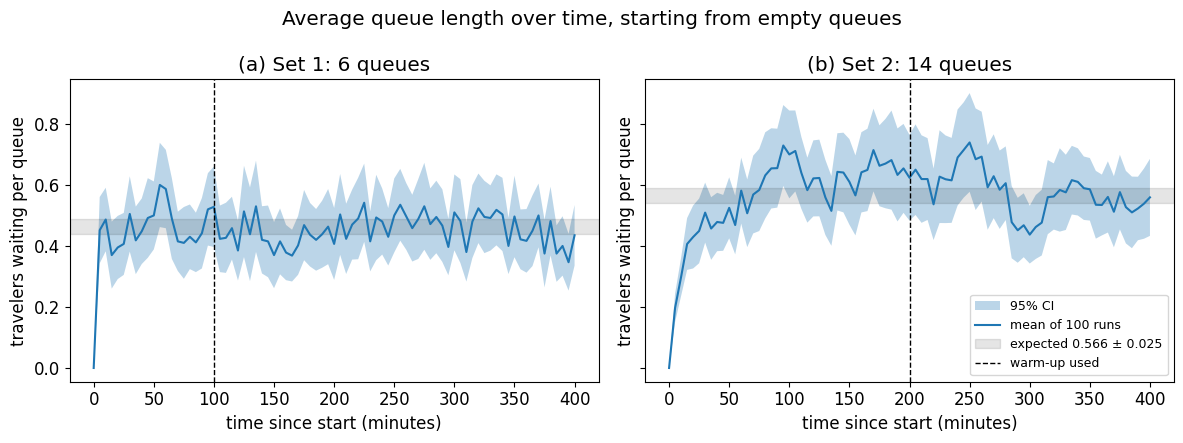

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (letter, (name, case)) in zip(axes, zip("ab", TEST_CASES.items())):
    warmup_check(ax, **case, title=f"({letter}) {name}: {case['num_queues']} queues")
axes[1].legend(fontsize=9, loc="lower right")
fig.suptitle("Average queue length over time, starting from empty queues")
plt.tight_layout(); plt.show()

### 5.2 Visualizing the state of the simulation

A short 30-minute run with the project parameters, showing how many travelers wait in each queue
over time. It lets us see that travelers spread out over the queues, that the lines stay balanced,
and that lengths never go negative.

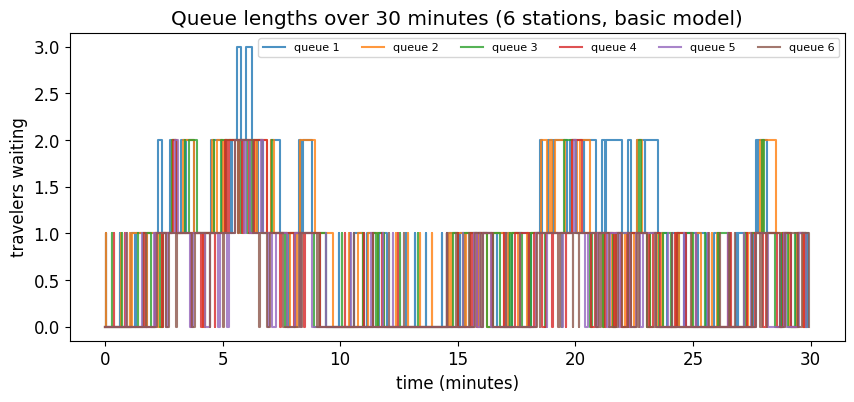

Queue lengths at the end: [2, 2, 2, 1, 1, 1] (shortest-queue joining keeps them balanced)
All structural checks passed.


In [10]:
airport = run_simulation(BASIC_MODEL, num_queues=6, run_until=30)

plt.figure(figsize=(10, 4))
for index, queue in enumerate(airport.queues):
    plt.step(queue.history_times, queue.history_lengths, where="post", alpha=0.8,
             label=f"queue {index + 1}")
plt.xlabel("time (minutes)"); plt.ylabel("travelers waiting")
plt.title("Queue lengths over 30 minutes (6 stations, basic model)")
plt.legend(ncol=6, fontsize=8); plt.show()

# Basic sanity checks that must hold in every run
for queue in airport.queues:
    assert min(queue.history_lengths) >= 0, "negative queue length"
    assert all(wait >= 0 for _, wait in queue.waiting_times), "negative waiting time"
    assert queue.people_being_served in (0, 1), "more than one traveler at a station"
lengths = [q.length() for q in airport.queues]
print("Queue lengths at the end:", lengths, "(shortest-queue joining keeps them balanced)")
print("All structural checks passed.")

### 5.3 Extra test cases


In [11]:
FAST_SERVICE = truncated_normal(0.01, 0.002)   # about 0.6 seconds per traveler
FAST_STATIONS, FAST_MINUTES = 10, 200
OVERLOAD_STATIONS, OVERLOAD_MINUTES = 4, 200   # 4 stations serve about 8 travelers/min
OVERLOAD_RUNS = 20
SINGLE_RATE = 1.5                              # travelers/min, so one station has rho ≈ 0.75
SINGLE_RUN_UNTIL, SINGLE_WARMUP, SINGLE_RUNS = 3000, 500, 10

# 1. Fast stations
fast = run_simulation(replace(BASIC_MODEL, service=FAST_SERVICE), FAST_STATIONS, FAST_MINUTES)
longest_wait = max(wait for queue in fast.queues for _, wait in queue.waiting_times)
print(f"Fast stations: longest wait = {longest_wait:.4f} min")

# 2. Overloaded: more travelers arrive than the stations can serve
backlogs = [sum(queue.people_in_queue for queue in
                run_simulation(BASIC_MODEL, OVERLOAD_STATIONS, OVERLOAD_MINUTES).queues)
            for _ in range(OVERLOAD_RUNS)]
mean, half = mean_and_ci(backlogs)
expected_growth = (ARRIVAL_RATE - OVERLOAD_STATIONS / BASIC_MODEL.service.mean()) * OVERLOAD_MINUTES
print(f"Overloaded: {mean:.0f} ± {half:.0f} waiting after {OVERLOAD_MINUTES} min, "
      f"expected about {expected_growth:.0f}")

# 3. Single queue vs M/G/1 theory (arrival rate lowered so the queue is stable)
single_queue = replace(BASIC_MODEL, arrival=sts.expon(scale=1 / SINGLE_RATE))
waits = repeat_runs(single_queue, 1, SINGLE_RUN_UNTIL, SINGLE_WARMUP, SINGLE_RUNS)["mean_wait"]
mean, half = mean_and_ci(waits)
theory = mg1_wait_time(SINGLE_RATE, BASIC_MODEL.service)
print(f"M/G/1 check: simulated wait {mean:.3f} ± {half:.3f} min, theory {theory:.3f} min")

Fast stations: longest wait = 0.0000 min
Overloaded: 413 ± 18 waiting after 200 min, expected about 402


M/G/1 check: simulated wait 0.821 ± 0.073 min, theory 0.838 min


### 5.4 Does the extension reduce to the basic model?



In [12]:
REDUCTION_STATIONS = 8

reductions = {
    "basic model": BASIC_MODEL,
    "p_s = 0": replace(EXTENDED_MODEL, p_extra=0.0),
    "mu2 = sigma2 = 0": replace(EXTENDED_MODEL, screening=truncated_normal(0, 0)),
}
for label, scenario in reductions.items():
    mean, half = mean_and_ci(repeat_runs(scenario, REDUCTION_STATIONS)["mean_length"])
    print(f"{label:18s}: mean queue length {mean:.3f} ± {half:.3f}")

basic model       : mean queue length 0.043 ± 0.002


p_s = 0           : mean queue length 0.044 ± 0.001


mu2 = sigma2 = 0  : mean queue length 0.042 ± 0.002


In [13]:
np.random.seed(RANDOM_SEED)   # fresh seed, so Part 2 is reproducible on its own
print("Basic model")
basic_results = study(BASIC_MODEL, STATION_COUNTS)

Basic model


k =  6 | wait    0.234 ±  0.0098 min | length     0.39 ±   0.017 | max   4.5 ±  0.4 | under 15 min 100.0% ± 0.0%


k =  7 | wait   0.0811 ±  0.0018 min | length    0.116 ±  0.0028 | max   2.4 ±  0.3 | under 15 min 100.0% ± 0.0%


k =  8 | wait   0.0344 ± 0.00084 min | length    0.043 ±  0.0011 | max   1.9 ±  0.2 | under 15 min 100.0% ± 0.0%


k =  9 | wait   0.0156 ± 0.00044 min | length   0.0174 ± 0.00052 | max   1.1 ±  0.2 | under 15 min 100.0% ± 0.0%


k = 10 | wait  0.00664 ± 0.00048 min | length  0.00665 ±  0.0005 | max   1.1 ±  0.1 | under 15 min 100.0% ± 0.0%


k = 11 | wait  0.00259 ± 0.00024 min | length  0.00236 ± 0.00022 | max   1.0 ±  0.0 | under 15 min 100.0% ± 0.0%


k = 12 | wait  0.00107 ± 0.00017 min | length 0.000892 ± 0.00014 | max   1.0 ±  0.0 | under 15 min 100.0% ± 0.0%


k = 13 | wait 0.000355 ± 7.2e-05 min | length 0.000273 ± 5.5e-05 | max   1.0 ±  0.0 | under 15 min 100.0% ± 0.0%


k = 14 | wait  0.00015 ± 5.5e-05 min | length 0.000107 ± 3.9e-05 | max   1.0 ±  0.0 | under 15 min 100.0% ± 0.0%


We also check the 100-minute warm-up on the basic model itself, with the same method as in
Section 5.1. We use 6 stations because it is the busiest case, so it should take the longest to
settle. The average queue length reaches the one-day average within about 10 to 20 minutes, well
before the warm-up ends.

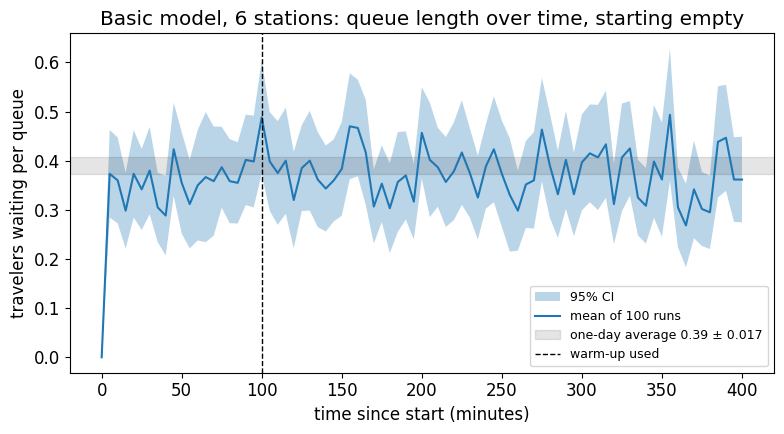

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
day_mean, day_half = basic_results[6]["mean_length"]
warmup_check(ax, BASIC_MODEL.service, 6, stationary_after=WARMUP, expected=day_mean,
             tolerance=day_half, band_label="one-day average",
             title="Basic model, 6 stations: queue length over time, starting empty")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()

To see the stability threshold directly, we also run the basic model with 4 and 5 stations,
where the utilization is above 1, and compare it with 6 stations. Each run lasts six days, and
the table shows the average number of travelers waiting on each day.

In [15]:
THRESHOLD_STATIONS = [4, 5, 6]
THRESHOLD_DAYS, THRESHOLD_RUNS = 6, 10
minutes = np.arange(0, THRESHOLD_DAYS * DAY_LENGTH, 1.0)

print(f"Basic model: average travelers waiting (all queues) on each day of a {THRESHOLD_DAYS}-day "
      f"run, mean of {THRESHOLD_RUNS} runs")
print("                   " + "".join(f"  day {day + 1:d}" for day in range(THRESHOLD_DAYS)))
for num_queues in THRESHOLD_STATIONS:
    daily = []
    for _ in range(THRESHOLD_RUNS):
        airport = run_simulation(BASIC_MODEL, num_queues, THRESHOLD_DAYS * DAY_LENGTH)
        total_waiting = waiting_over_time(airport, minutes).sum(axis=0)
        daily.append(total_waiting.reshape(THRESHOLD_DAYS, DAY_LENGTH).mean(axis=1))
    utilization = ARRIVAL_RATE * BASIC_MODEL.service.mean() / num_queues
    print(f"k = {num_queues} (rho = {utilization:.3f}): "
          + "".join(f"{value:7.0f}" for value in np.mean(daily, axis=0)))

Basic model: average travelers waiting (all queues) on each day of a 6-day run, mean of 10 runs
                     day 1  day 2  day 3  day 4  day 5  day 6


k = 4 (rho = 1.252):    1458   4419   7323  10184  13006  15852


k = 5 (rho = 1.001):      65    118    115    159    195    198


k = 6 (rho = 0.835):       2      2      2      2      2      2


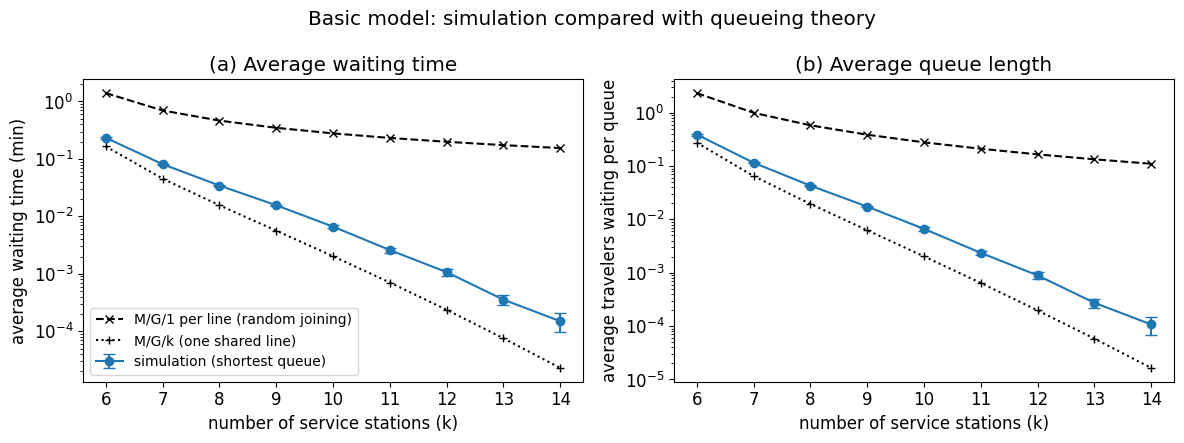

k =  6 | M/G/k    0.165 ≤ simulation    0.234 ≤ M/G/1    1.4 min
k =  7 | M/G/k   0.0454 ≤ simulation   0.0811 ≤ M/G/1  0.698 min
k =  8 | M/G/k   0.0156 ≤ simulation   0.0344 ≤ M/G/1  0.465 min
k =  9 | M/G/k  0.00564 ≤ simulation   0.0156 ≤ M/G/1  0.348 min
k = 10 | M/G/k  0.00203 ≤ simulation  0.00664 ≤ M/G/1  0.279 min
k = 11 | M/G/k 0.000706 ≤ simulation  0.00259 ≤ M/G/1  0.232 min
k = 12 | M/G/k 0.000236 ≤ simulation  0.00107 ≤ M/G/1  0.199 min
k = 13 | M/G/k 7.55e-05 ≤ simulation 0.000355 ≤ M/G/1  0.174 min
k = 14 | M/G/k  2.3e-05 ≤ simulation  0.00015 ≤ M/G/1  0.155 min


In [16]:
station_counts = np.array(list(basic_results))
per_queue_rates = ARRIVAL_RATE / station_counts
mg1_wait = np.array([mg1_wait_time(rate, BASIC_MODEL.service) for rate in per_queue_rates])
mgk_wait = np.array([mgk_wait_time(ARRIVAL_RATE, k, BASIC_MODEL.service) for k in station_counts])
theory = {
    "mean_wait": (mg1_wait, mgk_wait),
    "mean_length": (per_queue_rates * mg1_wait, ARRIVAL_RATE * mgk_wait / station_counts),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
panels = [("mean_wait", "(a) Average waiting time", "average waiting time (min)"),
          ("mean_length", "(b) Average queue length", "average travelers waiting per queue")]
for ax, (metric, title, ylabel) in zip(axes, panels):
    upper, lower = theory[metric]
    ax.plot(station_counts, upper, "k--", marker="x", label="M/G/1 per line (random joining)")
    plot_metric(ax, measurable(basic_results, metric), metric, label="simulation (shortest queue)")
    ax.plot(station_counts, lower, "k:", marker="+", label="M/G/k (one shared line)")
    ax.set_yscale("log"); ax.set_title(title)
    ax.set_xlabel("number of service stations (k)"); ax.set_ylabel(ylabel)
axes[0].legend(fontsize=10)
fig.suptitle("Basic model: simulation compared with queueing theory")
plt.tight_layout(); plt.show()

for k, sim, upper, lower in zip(station_counts, [basic_results[k]["mean_wait"][0] for k in station_counts],
                                mg1_wait, mgk_wait):
    print(f"k = {k:2d} | M/G/k {lower:8.3g} ≤ simulation {sim:8.3g} ≤ M/G/1 {upper:6.3g} min")

Average wait (min):  M/G/1 formula | simulation, random line | simulation, shortest line
k =  6:                1.401 |     1.427 ± 0.056 |     0.2337
k =  7:                0.698 |     0.709 ± 0.019 |    0.08105
k =  8:                0.465 |     0.471 ± 0.009 |    0.03444
k = 10:                0.279 |     0.279 ± 0.004 |   0.006636
k = 12:                0.199 |     0.198 ± 0.002 |    0.00107
k = 14:                0.155 |     0.155 ± 0.002 |  0.0001498

Line balance:      longest - shortest line (average, daily peak) | station idle while others wait
k =  6, random  :               6.39,  21.1 |              66.4%
k =  6, shortest:               0.66,   2.8 |              17.8%
k =  8, random  :               2.45,  10.8 |              92.6%
k =  8, shortest:               0.19,   2.0 |              11.4%
k = 10, random  :               1.63,   7.3 |              87.6%
k = 10, shortest:               0.05,   1.0 |               3.3%


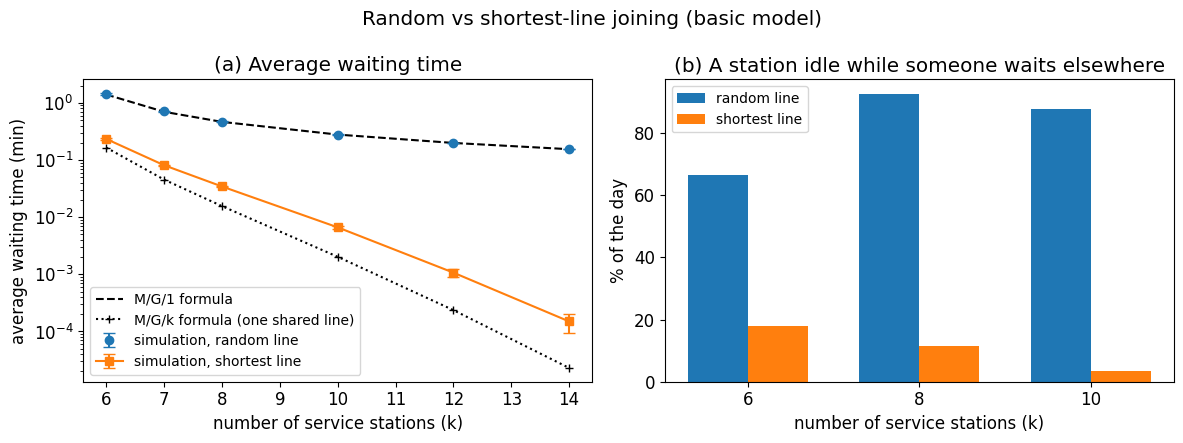

In [17]:
JOINING_STATIONS = [6, 7, 8, 10, 12, 14]
BALANCE_STATIONS = [6, 8, 10]
RANDOM_JOINING = replace(BASIC_MODEL, joining="random")

random_waits = {k: mean_and_ci(repeat_runs(RANDOM_JOINING, k)["mean_wait"]) for k in JOINING_STATIONS}
balance = {(rule, k): line_balance(scenario, k)
           for rule, scenario in [("random", RANDOM_JOINING), ("shortest", BASIC_MODEL)]
           for k in BALANCE_STATIONS}

print("Average wait (min):  M/G/1 formula | simulation, random line | simulation, shortest line")
for k in JOINING_STATIONS:
    mean, half = random_waits[k]
    print(f"k = {k:2d}: {mg1_wait_time(ARRIVAL_RATE / k, BASIC_MODEL.service):20.3f} | "
          f"{mean:9.3f} ± {half:.3f} | {basic_results[k]['mean_wait'][0]:10.4g}")
print("\nLine balance:      longest - shortest line (average, daily peak) | station idle while others wait")
for k in BALANCE_STATIONS:
    for rule in ("random", "shortest"):
        b = balance[(rule, k)]
        print(f"k = {k:2d}, {rule:8s}: {b['gap']:18.2f}, {b['peak_gap']:5.1f} | {b['wasted']:18.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ks = np.array(JOINING_STATIONS)
axes[0].plot(ks, [mg1_wait_time(ARRIVAL_RATE / k, BASIC_MODEL.service) for k in ks], "k--",
             label="M/G/1 formula")
axes[0].errorbar(ks, [random_waits[k][0] for k in ks], yerr=[random_waits[k][1] for k in ks],
                 marker="o", ls="none", capsize=4, label="simulation, random line")
plot_metric(axes[0], {k: basic_results[k] for k in ks}, "mean_wait",
            label="simulation, shortest line", marker="s")
axes[0].plot(ks, [mgk_wait_time(ARRIVAL_RATE, k, BASIC_MODEL.service) for k in ks], "k:",
             marker="+", label="M/G/k formula (one shared line)")
axes[0].set_yscale("log"); axes[0].set_title("(a) Average waiting time")
axes[0].set_xlabel("number of service stations (k)"); axes[0].set_ylabel("average waiting time (min)")
axes[0].legend(fontsize=10)

width = 0.35
positions = np.arange(len(BALANCE_STATIONS))
for offset, rule in [(-width / 2, "random"), (width / 2, "shortest")]:
    axes[1].bar(positions + offset, [100 * balance[(rule, k)]["wasted"] for k in BALANCE_STATIONS],
                width, label=f"{rule} line")
axes[1].set_xticks(positions, [str(k) for k in BALANCE_STATIONS])
axes[1].set_title("(b) A station idle while someone waits elsewhere")
axes[1].set_xlabel("number of service stations (k)"); axes[1].set_ylabel("% of the day")
axes[1].legend(fontsize=10)
fig.suptitle("Random vs shortest-line joining (basic model)")
plt.tight_layout(); plt.show()

### 6.2 Extended model: the senior officer



In [18]:
officer_utilization = EXTENDED_MODEL.p_extra * ARRIVAL_RATE * EXTENDED_MODEL.screening.mean()
print(f"Officer utilization estimate: {officer_utilization:.3f}")
print("\nExtended model")
np.random.seed(RANDOM_SEED)
extended_results = study(EXTENDED_MODEL, STATION_COUNTS_EXT,
                         run_until=RUN_UNTIL_EXT, warmup=WARMUP_EXT, num_runs=NUM_RUNS_EXT,
                         notes={6: "UNSTABLE: the queue keeps growing (Section 6.3)",
                                7: "stable but slow to settle (Section 6.3)"})

Officer utilization estimate: 0.773

Extended model


k =  6 | wait     64.7 ±     8.6 min | length      108 ±      14 | max 193.9 ± 21.3 | under 15 min   6.5% ± 3.7%  <- UNSTABLE: the queue keeps growing (Section 6.3)


k =  7 | wait     8.96 ±     2.9 min | length     12.9 ±     4.1 | max  44.8 ±  8.9 | under 15 min  78.5% ± 8.6%  <- stable but slow to settle (Section 6.3)


k =  8 | wait     3.25 ±     1.4 min | length     4.05 ±     1.7 | max  26.4 ±  5.8 | under 15 min  93.5% ± 3.7%


k =  9 | wait     2.26 ±    0.68 min | length     2.52 ±    0.76 | max  20.6 ±  3.6 | under 15 min  95.0% ± 1.9%


k = 10 | wait     1.05 ±    0.74 min | length     1.05 ±    0.74 | max  12.1 ±  3.3 | under 15 min  97.8% ± 2.0%


k = 11 | wait     1.07 ±     0.6 min | length    0.982 ±    0.55 | max  10.9 ±  3.0 | under 15 min  97.5% ± 1.6%


k = 12 | wait    0.705 ±    0.29 min | length    0.596 ±    0.24 | max   9.7 ±  2.5 | under 15 min  98.2% ± 0.8%


k = 13 | wait    0.831 ±    0.58 min | length    0.649 ±    0.46 | max   9.0 ±  3.4 | under 15 min  98.1% ± 1.3%


k = 14 | wait    0.448 ±    0.23 min | length    0.316 ±    0.16 | max   6.4 ±  2.3 | under 15 min  98.9% ± 0.6%


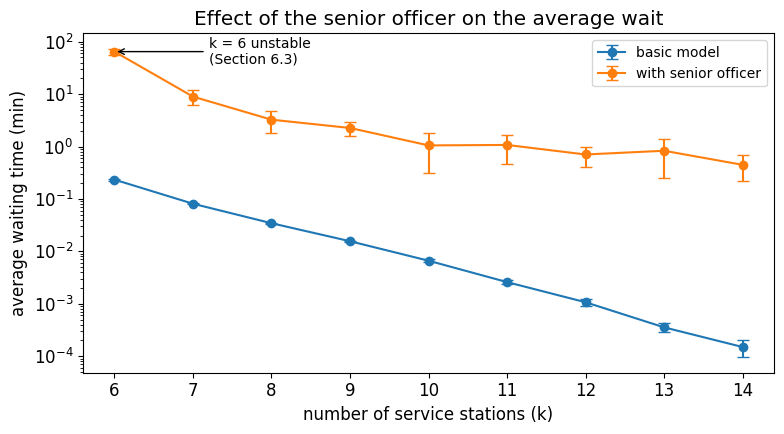

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for results, label in [(basic_results, "basic model"), (extended_results, "with senior officer")]:
    plot_metric(ax, measurable(results, "mean_wait"), "mean_wait", label=label)
unstable_wait = extended_results[6]["mean_wait"][0]
ax.annotate("k = 6 unstable\n(Section 6.3)", xy=(6, unstable_wait), xytext=(7.2, unstable_wait),
            va="center", fontsize=10, arrowprops={"arrowstyle": "->"})
ax.set_yscale("log"); ax.set_xlabel("number of service stations (k)")
ax.set_ylabel("average waiting time (min)"); ax.legend(fontsize=10)
ax.set_title("Effect of the senior officer on the average wait")
plt.tight_layout(); plt.show()

### 6.3 Is the extended model stationary?

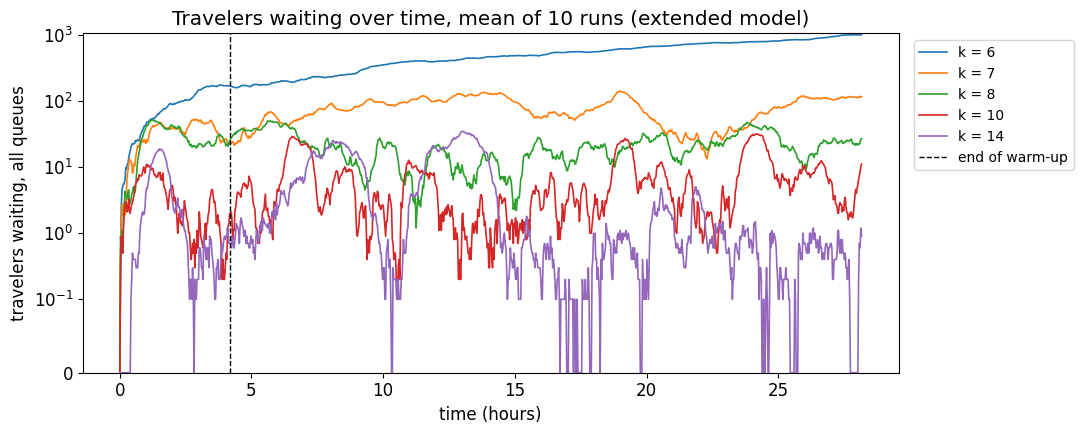

In [20]:
STABILITY_STATIONS = [6, 7, 8, 10, 14]
STABILITY_DAYS, STABILITY_RUNS = 6, 10   # days per run in the table below; runs averaged
grid = np.linspace(0, RUN_UNTIL_EXT, 1000)   # minutes

fig, ax = plt.subplots(figsize=(11, 4.5))
for num_queues in STABILITY_STATIONS:
    total_waiting = np.mean([waiting_over_time(run_simulation(EXTENDED_MODEL, num_queues,
                                                              RUN_UNTIL_EXT), grid).sum(axis=0)
                             for _ in range(STABILITY_RUNS)], axis=0)
    ax.plot(grid / 60, total_waiting, lw=1.2, label=f"k = {num_queues}")
ax.axvline(WARMUP_EXT / 60, color="k", ls="--", lw=1, label="end of warm-up")
ax.set_yscale("symlog", linthresh=0.1); ax.set_ylim(bottom=0)
ax.set_xlabel("time (hours)"); ax.set_ylabel("travelers waiting, all queues")
ax.set_title(f"Travelers waiting over time, mean of {STABILITY_RUNS} runs (extended model)")
ax.legend(fontsize=10, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout(); plt.show()

In [21]:
minutes = np.arange(0, STABILITY_DAYS * DAY_LENGTH, 1.0)
print(f"Average travelers waiting (all queues) on each day of a {STABILITY_DAYS}-day run, "
      f"mean of {STABILITY_RUNS} runs")
print("        " + "".join(f"  day {day + 1:d}" for day in range(STABILITY_DAYS)))
for num_queues in STABILITY_STATIONS[:3]:
    daily = []
    for _ in range(STABILITY_RUNS):
        airport = run_simulation(EXTENDED_MODEL, num_queues, STABILITY_DAYS * DAY_LENGTH)
        total_waiting = waiting_over_time(airport, minutes).sum(axis=0)
        daily.append(total_waiting.reshape(STABILITY_DAYS, DAY_LENGTH).mean(axis=1))
    print(f"k = {num_queues:2d}: " + "".join(f"{value:7.0f}" for value in np.mean(daily, axis=0)))

Average travelers waiting (all queues) on each day of a 6-day run, mean of 10 runs
          day 1  day 2  day 3  day 4  day 5  day 6


k =  6:     532   1546   2482   3572   4552   5568


k =  7:     102     85    100     87     99     94


k =  8:      33     23     30     31     26     34


**6 stations is unstable.** The number of people waiting keeps climbing, by roughly a thousand
travelers per day. There is no steady state, so the 64.7-minute average wait for $k = 6$ only
tells us how long we simulated, and its ± value is not a real confidence interval.

**7 stations is stable, but only just.** Over six days its daily averages stay between about 85
and 102 travelers waiting, with no upward trend. In the figure, though, the 7-station curve keeps
rising for several hours after the warm-up before it levels off, so its one-day values in Section
6.2 may be a little low.

**From 8 stations up, the system is stationary.** The lines go up and down around a stable level
and have already settled when the 250-minute warm-up ends. So the warm-up is long enough, and the
confidence intervals are meaningful for $k \ge 8$.

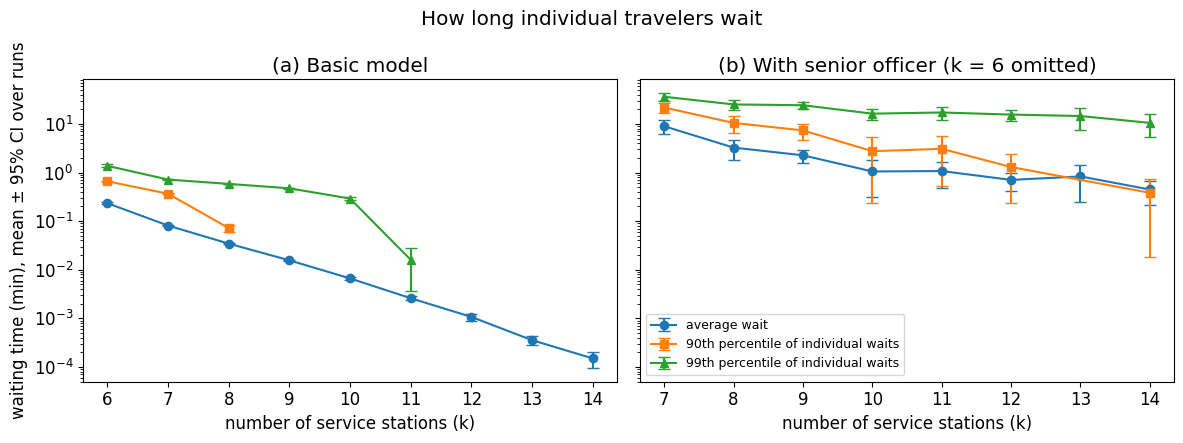

basic    k =  6: average  0.234 min | 90th pct  0.659 min | 99th pct  1.374 ± 0.089 min
basic    k =  8: average  0.034 min | 90th pct  0.072 min | 99th pct  0.583 ± 0.008 min
basic    k = 10: average  0.007 min | 90th pct  0.000 min | 99th pct  0.291 ± 0.018 min
extended k =  8: average  3.253 min | 90th pct 10.481 min | 99th pct 25.153 ± 6.149 min
extended k = 10: average  1.051 min | 90th pct  2.744 min | 99th pct 16.248 ± 4.132 min
extended k = 12: average  0.705 min | 90th pct  1.298 min | 99th pct 15.553 ± 4.213 min
extended k = 14: average  0.448 min | 90th pct  0.383 min | 99th pct 10.508 ± 5.168 min


In [22]:
stable_extended = {k: row for k, row in extended_results.items() if k != 6}
statistics = [("mean_wait", "average wait", "o"),
              ("p90_wait", "90th percentile of individual waits", "s"),
              ("p99_wait", "99th percentile of individual waits", "^")]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (results, title) in zip(axes, [(basic_results, "(a) Basic model"),
                                       (stable_extended, "(b) With senior officer (k = 6 omitted)")]):
    for metric, label, marker in statistics:
        plot_metric(ax, measurable(results, metric), metric, label=label, marker=marker)
    ax.set_yscale("log"); ax.set_title(title); ax.set_xlabel("number of service stations (k)")
axes[0].set_ylabel("waiting time (min), mean ± 95% CI over runs")
axes[1].legend(fontsize=9, loc="lower left")
fig.suptitle("How long individual travelers wait")
plt.tight_layout(); plt.show()

for label, results, counts in [("basic", basic_results, (6, 8, 10)),
                               ("extended", extended_results, (8, 10, 12, 14))]:
    for k in counts:
        row = results[k]
        print(f"{label:8s} k = {k:2d}: average {row['mean_wait'][0]:6.3f} min | 90th pct "
              f"{row['p90_wait'][0]:6.3f} min | 99th pct {row['p99_wait'][0]:6.3f} ± {row['p99_wait'][1]:5.3f} min")

In the basic model even the unluckiest travelers barely wait: the 99th percentile is 1.4 minutes
at 6 stations and 0.3 minutes at 10. With the senior officer the picture is very different. At 10
stations the average wait is 1.05 minutes, but 1 traveler in 100 waits 16.2 ± 4.1 minutes, and even
at 14 stations it is 10.5 ± 5.2 minutes. The 90th percentile drops much faster (10.5 minutes at 8
stations, 2.7 at 10, 1.3 at 12), so adding stations mostly helps the typical traveler.

At 14 stations the average (0.45 minutes) is even higher than the 90th percentile (0.38 minutes).
This looks odd but is expected: more than 90% of travelers barely wait, and the average is pulled
up by a few very long waits. Those long waits happen when the senior officer falls behind, and
extra stations only shorten them slowly.

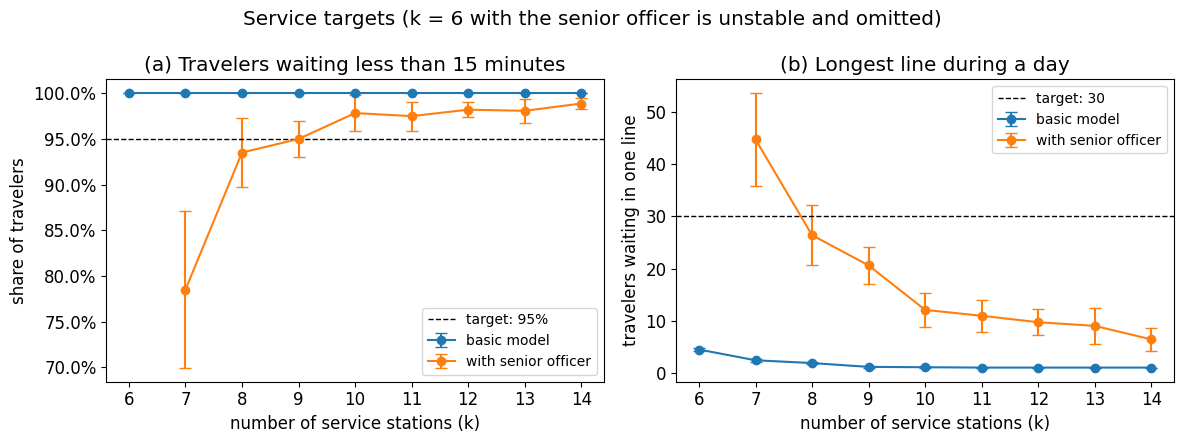

Basic model: smallest k meeting both targets = 6
With senior officer: smallest k meeting both targets = 10


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for results, label in [(basic_results, "basic model"), (stable_extended, "with senior officer")]:
    plot_metric(axes[0], results, "within_target", label=label)
    plot_metric(axes[1], results, "max_length", label=label)
axes[0].axhline(TARGET_SHARE, color="k", ls="--", lw=1, label=f"target: {TARGET_SHARE:.0%}")
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
axes[0].set_title(f"(a) Travelers waiting less than {TARGET_WAIT:.0f} minutes")
axes[0].set_ylabel("share of travelers")
axes[1].axhline(TARGET_MAX_LINE, color="k", ls="--", lw=1, label=f"target: {TARGET_MAX_LINE:.0f}")
axes[1].set_title("(b) Longest line during a day")
axes[1].set_ylabel("travelers waiting in one line")
for ax in axes:
    ax.set_xlabel("number of service stations (k)"); ax.legend(fontsize=10)
fig.suptitle("Service targets (k = 6 with the senior officer is unstable and omitted)")
plt.tight_layout(); plt.show()

for label, results in [("Basic model", basic_results), ("With senior officer", stable_extended)]:
    meeting = [k for k, row in results.items() if meets_targets(row)]
    print(f"{label}: smallest k meeting both targets = {min(meeting) if meeting else 'none tested'}")

<a id="references"></a>
## References and acknowledgments

**Course materials**

* CS166 First Project assignment, *Airport Security Queues*: model description, parameters, and
  the two test cases.
* CS166 Session 2, *[1.2] Queueing theory*, pre-class workbook (Minerva University, Fall 2026):
  M/G/1 average waiting time (the Pollaczek–Khinchine formula), M/M/c waiting time with the Erlang
  C formula, Little's law, and the idea of equilibrium (Sections 5.3 and 6.1).
* CS166 Session 3, *[2.1] Implementing a simulation*: screencast and code notebook *Simulations
  with schedules*,
  https://course-resources.minerva.edu/uploaded_files/mke/00229796-8438/simulations-with-schedules.ipynb.
  The `Event` and `Schedule` classes in Section 2 are adapted from it.
* CS166 Session 4, *[2.2] Empirical analysis*, pre-class workbook (Minerva University, Fall 2026):
  95% confidence intervals of the mean with the t-distribution (Sections 5 and 6).
* Gosavi, A. (n.d.). *Tutorial for use of basic queueing formulas*. Missouri University of Science
  and Technology. https://simoptim.com/main/queuing_formulas.pdf (linked from the Session 2
  workbook): two-moment approximation for M/G/c queues (Section 6.1).

<!-- TODO: add the course readings we used (e.g. Session 3 and 4 readings) -->

**Other sources**

* Law, A. M. (2023). Design and analysis of simulation experiments using three simple statistical
  formulas. In C. G. Corlu, S. R. Hunter, H. Lam, B. S. Onggo, J. Shortle, & B. Biller (Eds.),
  *Proceedings of the 2023 Winter Simulation Conference*. https://informs-sim.org/wsc23papers/124.pdf
  (percentiles estimated from independent runs; Section 6.4).
* Weitz, D. (2022, July 14). Simulation with SimPy, Part 8: Output data analysis for
  non-terminating simulations. *Towards Data Science*.
  https://medium.com/data-science/simulation-with-simpy-7dfefaea801e (Welch's method for choosing
  a warm-up period; Sections 5.1 and 6).

**AI tools**

We used Cursor (an AI coding agent) to refactor the code (type hints, moving the helper functions
into Section 4, `Scenario` objects instead of global variables, and batched random draws), to
extend the analysis (the M/G/k comparison, measuring over a full day, the warm-up and stationarity
checks, waiting-time percentiles, and the service targets), and creating figures.